# Spatial Branch — Final Training (From Scratch)

## Plan
- Train from scratch — no patching old model
- Real class: FF++ Real + LFW (covers all real domains)
- Fake class: FF++ 6 manipulation types only
- Phone images: held-out test only (not face crops — wrong format for training)
- CelebDF: held-out cross-dataset test only
- Improved augmentation including random erasing
- No pos_weight, no sampler — diversity of real sources is the fix
- Pareto threshold after training (defensible, standard practice)

In [1]:
import os, io, gc, random
from pathlib import Path
from dataclasses import dataclass
from collections import Counter

import numpy as np
from PIL import Image, ImageFilter, ImageEnhance
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from torchvision import transforms
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_curve, auc
)
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [2]:
# ══════════════════════════════════════════
#  CONFIG
# ══════════════════════════════════════════
SEED        = 42
DEVICE      = 'cuda' if torch.cuda.is_available() else 'cpu'

# Training from scratch — full LR, full epochs
START_EPOCH = 0
EPOCHS      = 15
BATCH_SIZE  = 32
LR          = 1e-4
LR_MIN      = 1e-6
WEIGHT_DECAY= 1e-4
GRAD_CLIP   = 1.0
# No pos_weight — real diversity handles imbalance

TARGET_SIZE   = 224
RESIZE_SIZE   = 256
IMG_EXTS      = {'.jpg','.jpeg','.png','.webp','.bmp'}
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

FF_CAP_PER_TYPE = None   # use all FF++ images
LFW_CAP         = 13000  # full LFW
CELEB_FAKE_CAP  = 15000
CELEB_REAL_CAP  = 8000
FAST_VAL_N      = 4000

CKPT_LOAD = None   # training from scratch
CKPT_DIR  = '/kaggle/working'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

print('Device:', DEVICE)
print('Training from scratch — START_EPOCH=0')
print('Config OK')

Device: cuda
Training from scratch — START_EPOCH=0
Config OK


In [3]:
# ══════════════════════════════════════════
#  PATHS
#
#  Real sources for training:
#    FF++ Real — controlled lab video frames
#    LFW       — diverse uncontrolled real faces
#                (linear probe proved: 98.86% recall on phone images)
#
#  Phone images (Nathia Gali): NOT used in training
#    Reason: full-body outdoor shots, not face crops
#    Use case: held-out test after fusion
#
#  CelebDF: held-out cross-dataset test only
# ══════════════════════════════════════════
FF_SPLIT_ROOT = Path('/kaggle/input/datasets/gradientvoyager/faceforensics-c23-extracted-faces-100k/dataset_processed_split')
LFW_ROOT      = Path('/kaggle/input/datasets/jessicali9530/lfw-dataset/lfw-deepfunneled/lfw-deepfunneled')
CELEB_ROOT    = Path('/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2')

FF_FAKE_TYPES = [
    'Deepfakes', 'Face2Face', 'FaceShifter',
    'FaceSwap', 'NeuralTextures', 'DeepFakeDetection'
]
FF_REAL_NAME = 'Real'

for name, p in [
    ('FF++ split root', FF_SPLIT_ROOT),
    ('LFW root',        LFW_ROOT),
    ('CelebDF root',    CELEB_ROOT),
]:
    print(f'  {name:20s}: {"OK" if p.exists() else "MISSING"}')

print('\nFF++ image counts:')
for split in ['train','val','test']:
    sd = FF_SPLIT_ROOT / split
    if not sd.exists(): continue
    print(f'  {split}/')
    for folder in sorted(sd.iterdir()):
        if folder.is_dir():
            n = sum(1 for f in folder.rglob('*')
                    if f.suffix.lower() in IMG_EXTS)
            print(f'    {folder.name}: {n:,}')

  FF++ split root     : OK
  LFW root            : OK
  CelebDF root        : OK

FF++ image counts:
  train/
    DeepFakeDetection: 19,880
    Deepfakes: 18,085
    Face2Face: 18,365
    FaceShifter: 17,481
    FaceSwap: 18,885
    NeuralTextures: 17,390
    Real: 18,391
  val/
    DeepFakeDetection: 3,285
    Deepfakes: 4,017
    Face2Face: 4,105
    FaceShifter: 3,889
    FaceSwap: 4,209
    NeuralTextures: 3,879
    Real: 4,109
  test/
    DeepFakeDetection: 3,000
    Deepfakes: 3,875
    Face2Face: 3,954
    FaceShifter: 3,715
    FaceSwap: 4,044
    NeuralTextures: 3,744
    Real: 3,944


In [4]:
@dataclass(frozen=True)
class SampleRef:
    path:   str
    label:  int    # 0=real  1=fake
    source: str

def list_images(p: Path):
    if not p.exists(): return []
    return [x for x in p.rglob('*')
            if x.is_file() and x.suffix.lower() in IMG_EXTS]

def cap_shuffle(paths, cap):
    random.shuffle(paths)
    return paths[:cap] if cap and len(paths) > cap else paths

print('SampleRef defined.')

SampleRef defined.


In [5]:
# ══════════════════════════════════════════
#  BUILD FF++ + LFW SPLITS
#
#  FF++ split used EXACTLY as provided.
#  Never re-split FF++ randomly — causes leakage
#  (frames from same video would appear in train AND test).
#
#  LFW split by identity (person-disjoint splits):
#  All images of one person stay in same split.
#  This is the correct way — if same person appears in
#  both train and test, accuracy is inflated.
# ══════════════════════════════════════════
train_refs, val_refs, test_refs = [], [], []

for split_name, ref_list in [('train', train_refs),
                              ('val',   val_refs),
                              ('test',  test_refs)]:
    sd = FF_SPLIT_ROOT / split_name
    if not sd.exists():
        print(f'WARNING: {sd} not found'); continue

    # FF++ Real
    rp = cap_shuffle(list_images(sd / FF_REAL_NAME), FF_CAP_PER_TYPE)
    ref_list += [SampleRef(str(p), 0, 'ff_Real') for p in rp]

    # FF++ Fake — all 6 manipulation types
    for ft in FF_FAKE_TYPES:
        fd = sd / ft
        if not fd.exists():
            print(f'  SKIP {ft} — not found'); continue
        fp = cap_shuffle(list_images(fd), FF_CAP_PER_TYPE)
        ref_list += [SampleRef(str(p), 1, f'ff_{ft}') for p in fp]

# LFW: identity-disjoint split 75/10/15
all_ids = sorted([d for d in LFW_ROOT.iterdir() if d.is_dir()])
random.shuffle(all_ids)
n      = len(all_ids)
nt, nv = int(0.75*n), int(0.10*n)

def lfw_from_ids(id_dirs, cap):
    paths = []
    for d in id_dirs:
        paths += list_images(d)
    return cap_shuffle(paths, cap)

lfw_tr = lfw_from_ids(all_ids[:nt],       int(LFW_CAP*0.75))
lfw_va = lfw_from_ids(all_ids[nt:nt+nv],  int(LFW_CAP*0.10))
lfw_te = lfw_from_ids(all_ids[nt+nv:],    LFW_CAP - int(LFW_CAP*0.75) - int(LFW_CAP*0.10))

train_refs += [SampleRef(str(p), 0, 'lfw_real') for p in lfw_tr]
val_refs   += [SampleRef(str(p), 0, 'lfw_real') for p in lfw_va]
test_refs  += [SampleRef(str(p), 0, 'lfw_real') for p in lfw_te]

random.shuffle(train_refs)
random.shuffle(val_refs)
random.shuffle(test_refs)

print('Splits:')
for name, refs in [('Train',train_refs),('Val',val_refs),('Test',test_refs)]:
    lc = Counter(r.label  for r in refs)
    sc = Counter(r.source for r in refs)
    print(f'\n  {name}: {len(refs):,}  real={lc[0]:,}  fake={lc[1]:,}  ratio={lc[1]/max(lc[0],1):.1f}:1')
    for s,c in sorted(sc.items()): print(f'    {s}: {c:,}')

Splits:

  Train: 138,227  real=28,141  fake=110,086  ratio=3.9:1
    ff_DeepFakeDetection: 19,880
    ff_Deepfakes: 18,085
    ff_Face2Face: 18,365
    ff_FaceShifter: 17,481
    ff_FaceSwap: 18,885
    ff_NeuralTextures: 17,390
    ff_Real: 18,391
    lfw_real: 9,750

  Val: 28,675  real=5,291  fake=23,384  ratio=4.4:1
    ff_DeepFakeDetection: 3,285
    ff_Deepfakes: 4,017
    ff_Face2Face: 4,105
    ff_FaceShifter: 3,889
    ff_FaceSwap: 4,209
    ff_NeuralTextures: 3,879
    ff_Real: 4,109
    lfw_real: 1,182

  Test: 28,122  real=5,790  fake=22,332  ratio=3.9:1
    ff_DeepFakeDetection: 3,000
    ff_Deepfakes: 3,875
    ff_Face2Face: 3,954
    ff_FaceShifter: 3,715
    ff_FaceSwap: 4,044
    ff_NeuralTextures: 3,744
    ff_Real: 3,944
    lfw_real: 1,846


In [6]:
# CelebDF — held-out cross-dataset test, never trained on
celeb_fake_paths, celeb_real_paths = [], []
for sn in ['Train','Val','Test']:
    sd = CELEB_ROOT / sn
    if not sd.exists(): continue
    for fn in ['fake','Fake']:
        fd = sd/fn
        if fd.exists(): celeb_fake_paths += list_images(fd); break
    for rn in ['real','Real']:
        rd = sd/rn
        if rd.exists(): celeb_real_paths += list_images(rd); break

print(f'CelebDF raw: real={len(celeb_real_paths):,}  fake={len(celeb_fake_paths):,}')
celeb_fake_paths = cap_shuffle(celeb_fake_paths, CELEB_FAKE_CAP)
celeb_real_paths = cap_shuffle(celeb_real_paths, CELEB_REAL_CAP)
celeb_refs  = [SampleRef(str(p),1,'celebdf_fake') for p in celeb_fake_paths]
celeb_refs += [SampleRef(str(p),0,'celebdf_real') for p in celeb_real_paths]
random.shuffle(celeb_refs)
cc = Counter(r.label for r in celeb_refs)
print(f'CelebDF test set: {len(celeb_refs):,}  real={cc[0]:,}  fake={cc[1]:,}')

CelebDF raw: real=50,360  fake=50,671
CelebDF test set: 23,000  real=8,000  fake=15,000


In [7]:
# ══════════════════════════════════════════
#  AUGMENTATION — THE ACTUAL BIAS FIX
#
#  Your friend's experience: improved preprocessing
#  removed bias better than any architecture change.
#  Here is why:
#
#  Without strong augmentation, the model memorizes
#  dataset-specific patterns:
#  'FF++ real = specific compression + lighting'
#  'FF++ fake = specific manipulation texture'
#  When it sees a phone image, it has no FF++ real
#  statistics to match, so it defaults to fake.
#
#  With strong augmentation, those statistics are
#  destroyed during training. The model is forced
#  to learn genuine discriminative features:
#  - Blending boundaries (face swap artifacts)
#  - Texture inconsistencies (reenactment artifacts)
#  - Identity-level anomalies
#  These generalize across domains.
#
#  New vs v1: wider blur/JPEG, brightness/contrast/
#  saturation jitter, grayscale, sharpening, random erasing
#
#  ORDER: Geometric -> Photometric -> Degradation -> Structural
#  Applied AFTER resize+crop, BEFORE tensor conversion
# ══════════════════════════════════════════
def random_erase(img: Image.Image, p=0.3) -> Image.Image:
    """
    Randomly erases a rectangular patch (2-15% of image area).
    Forces model to learn local artifacts, not global face structure.
    Key for removing FF++ memorization bias.
    """
    if random.random() >= p:
        return img
    w, h  = img.size
    area  = w * h
    # patch covers 2-15% of image
    patch_area = random.uniform(0.02, 0.15) * area
    ratio      = random.uniform(0.3, 3.0)
    ph = int((patch_area / ratio) ** 0.5)
    pw = int(ph * ratio)
    ph = min(ph, h)
    pw = min(pw, w)
    x0 = random.randint(0, max(1, w - pw))
    y0 = random.randint(0, max(1, h - ph))
    # fill with random noise (not zeros — zeros are unrealistic)
    patch = Image.fromarray(
        np.random.randint(0, 256, (ph, pw, 3), dtype=np.uint8)
    )
    img = img.copy()
    img.paste(patch, (x0, y0))
    return img


def augment_train(img: Image.Image) -> Image.Image:

    # ── 1. Geometric ──
    if random.random() < 0.5:
        img = img.transpose(Image.FLIP_LEFT_RIGHT)

    if random.random() < 0.4:
        img = img.rotate(random.uniform(-15, 15),
                         resample=Image.BICUBIC, expand=False)

    # ── 2. Photometric ──
    # Wide range covers phone exposure variation
    if random.random() < 0.5:
        img = ImageEnhance.Brightness(img).enhance(random.uniform(0.5, 1.5))

    if random.random() < 0.5:
        img = ImageEnhance.Contrast(img).enhance(random.uniform(0.6, 1.4))

    if random.random() < 0.4:
        img = ImageEnhance.Color(img).enhance(random.uniform(0.6, 1.4))

    # Random grayscale — prevents colour-channel bias
    # LFW has B&W images so model must not rely on colour
    if random.random() < 0.05:
        img = img.convert('L').convert('RGB')

    # ── 3. Degradation ──
    # Wide blur range: covers motion blur, out-of-focus phone photos
    # Model must NOT learn 'sharp = real' — many real photos are blurry
    if random.random() < 0.5:
        img = img.filter(ImageFilter.GaussianBlur(
                         radius=random.uniform(0.3, 2.5)))

    # Wide JPEG range: covers WhatsApp (low quality) to original (high)
    if random.random() < 0.6:
        buf = io.BytesIO()
        img.save(buf, format='JPEG', quality=random.randint(30, 95))
        buf.seek(0)
        img = Image.open(buf).convert('RGB')

    # Sharpening: covers phone portrait mode over-sharpening
    if random.random() < 0.2:
        img = ImageEnhance.Sharpness(img).enhance(random.uniform(0.0, 3.0))

    # Gaussian noise simulation
    if random.random() < 0.2:
        arr   = np.array(img, dtype=np.float32)
        noise = np.random.normal(0, random.uniform(2, 10), arr.shape)
        arr   = np.clip(arr + noise, 0, 255).astype(np.uint8)
        img   = Image.fromarray(arr)

    # ── 4. Structural ──
    # Random erasing: forces model to learn local artifacts
    # not global face statistics — key bias fix
    img = random_erase(img, p=0.3)

    return img


to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print('Augmentation pipeline defined.')
print('Includes: flip, rotation, brightness, contrast, saturation,')
print('          grayscale, blur(0.3-2.5), JPEG(30-95), sharpening,')
print('          gaussian noise, random erasing (NEW)')

Augmentation pipeline defined.
Includes: flip, rotation, brightness, contrast, saturation,
          grayscale, blur(0.3-2.5), JPEG(30-95), sharpening,
          gaussian noise, random erasing (NEW)


In [9]:
class SpatialDataset(Dataset):
    def __init__(self, refs, train=True):
        self.refs  = refs
        self.train = train

    def __len__(self): return len(self.refs)

    def __getitem__(self, idx):
        r = self.refs[idx]
        try:
            img = Image.open(r.path).convert('RGB')
        except Exception:
            return (torch.zeros(3, TARGET_SIZE, TARGET_SIZE),
                    torch.tensor(0.0), r.source)

        # Step 1: resize + center crop (always)
        img  = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.BICUBIC)
        left = (RESIZE_SIZE - TARGET_SIZE) // 2
        img  = img.crop((left, left, left + TARGET_SIZE, left + TARGET_SIZE))

        # Step 2: augment at 224px (correct scale for blur/JPEG)
        if self.train:
            img = augment_train(img)

        # Step 3: tensor + ImageNet normalise
        return to_tensor_norm(img), torch.tensor(float(r.label)), r.source

print('SpatialDataset defined.')

SpatialDataset defined.


In [10]:
fast_val_refs = random.sample(val_refs, min(FAST_VAL_N, len(val_refs)))

train_ds    = SpatialDataset(train_refs,    train=True)
fast_val_ds = SpatialDataset(fast_val_refs, train=False)
val_ds      = SpatialDataset(val_refs,      train=False)
test_ds     = SpatialDataset(test_refs,     train=False)
celeb_ds    = SpatialDataset(celeb_refs,    train=False)

KW_T = dict(num_workers=4, pin_memory=True)
KW_E = dict(num_workers=2, pin_memory=True)

train_loader    = DataLoader(train_ds,    batch_size=BATCH_SIZE, shuffle=True,  **KW_T)
fast_val_loader = DataLoader(fast_val_ds, batch_size=BATCH_SIZE, shuffle=False, **KW_E)
val_loader      = DataLoader(val_ds,      batch_size=BATCH_SIZE, shuffle=False, **KW_E)
test_loader     = DataLoader(test_ds,     batch_size=BATCH_SIZE, shuffle=False, **KW_E)
celeb_loader    = DataLoader(celeb_ds,    batch_size=BATCH_SIZE, shuffle=False, **KW_E)

print(f'train:    {len(train_ds):,}  ({len(train_loader):,} batches/epoch)')
print(f'fast_val: {len(fast_val_ds):,}')
print(f'val:      {len(val_ds):,}')
print(f'test:     {len(test_ds):,}')
print(f'celeb:    {len(celeb_ds):,}  (held-out)')

# Sanity check
x, y, src = next(iter(train_loader))
print(f'\nBatch: {x.shape}  y: {y.unique().tolist()}')
print(f'x range: [{x.min():.2f}, {x.max():.2f}]  (expected ~[-2.1, 2.6])')
print(f'Sources in batch: {list(set(src))[:4]}')
del x, y, src

tc = Counter(r.label for r in train_refs)
print(f'\nClass balance: real={tc[0]:,}  fake={tc[1]:,}  ratio={tc[1]/max(tc[0],1):.1f}:1')
print('LFW added diversity reduces original 6:1 ratio')
print('Real diversity (not weighting) is the correct fix')

train:    138,227  (4,320 batches/epoch)
fast_val: 4,000
val:      28,675
test:     28,122
celeb:    23,000  (held-out)

Batch: torch.Size([32, 3, 224, 224])  y: [0.0, 1.0]
x range: [-2.12, 2.64]  (expected ~[-2.1, 2.6])
Sources in batch: ['ff_DeepFakeDetection', 'ff_Face2Face', 'ff_Deepfakes', 'ff_NeuralTextures']

Class balance: real=28,141  fake=110,086  ratio=3.9:1
LFW added diversity reduces original 6:1 ratio
Real diversity (not weighting) is the correct fix


In [11]:
def build_model():
    m = efficientnet_b3(weights=EfficientNet_B3_Weights.IMAGENET1K_V1)
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(m.classifier[1].in_features, 1)
    )
    return m

model = build_model().to(DEVICE)
print(f'EfficientNet-B3: {sum(p.numel() for p in model.parameters())/1e6:.1f}M params')
print(f'Head: {model.classifier}')

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 162MB/s] 


EfficientNet-B3: 10.7M params
Head: Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1536, out_features=1, bias=True)
)


In [12]:
# No pos_weight — LFW provides real diversity
# Adding pos_weight on top would re-introduce fake-bias
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(1, EPOCHS - START_EPOCH), eta_min=LR_MIN
)
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=='cuda'))

print('BCEWithLogitsLoss (no pos_weight)')
print(f'AdamW lr={LR}  CosineAnnealing T_max={EPOCHS}')

BCEWithLogitsLoss (no pos_weight)
AdamW lr=0.0001  CosineAnnealing T_max=15


In [13]:
best_val_f1 = 0.0

if CKPT_LOAD and os.path.exists(CKPT_LOAD):
    ckpt = torch.load(CKPT_LOAD, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    if 'scheduler_state_dict' in ckpt:
        scheduler.load_state_dict(ckpt['scheduler_state_dict'])
    START_EPOCH = ckpt.get('epoch', 0)
    best_val_f1 = ckpt.get('best_val_f1', 0.0)
    scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE=='cuda'))
    print(f'Resumed epoch {START_EPOCH}, best_val_f1={best_val_f1:.4f}')
else:
    print('Starting from scratch (CKPT_LOAD=None)')

Starting from scratch (CKPT_LOAD=None)


In [15]:
THRESHOLD = 0.50

@torch.no_grad()
def evaluate(model, loader, desc='Eval', threshold=THRESHOLD):
    model.eval()
    pa, la, sa, probs_all = [], [], [], []
    for x, y, src in tqdm(loader, desc=desc, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE=='cuda')):
            logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).long()
        pa.extend(preds.cpu().tolist())
        la.extend(y.long().cpu().tolist())
        sa.extend(src if isinstance(src,(list,tuple)) else [src])
        probs_all.extend(probs.cpu().tolist())

    ov = {
        'acc':       accuracy_score(la, pa),
        'macro_f1':  f1_score(la, pa, average='macro',  zero_division=0),
        'real_f1':   f1_score(la, pa, pos_label=0,      zero_division=0),
        'fake_f1':   f1_score(la, pa, pos_label=1,      zero_division=0),
        'real_prec': precision_score(la, pa, pos_label=0, zero_division=0),
        'real_rec':  recall_score(la, pa, pos_label=0,    zero_division=0),
        'fake_prec': precision_score(la, pa, pos_label=1, zero_division=0),
        'fake_rec':  recall_score(la, pa, pos_label=1,    zero_division=0),
        'mean_prob': float(np.mean(probs_all)),
    }
    per = {}
    for s in set(sa):
        idx = [i for i,ss in enumerate(sa) if ss==s]
        yt  = [la[i] for i in idx]
        yp  = [pa[i] for i in idx]
        pl  = 0 if yt[0]==0 else 1
        per[s] = {
            'acc':  accuracy_score(yt,yp),
            'f1':   f1_score(yt,yp,pos_label=pl,zero_division=0),
            'prec': precision_score(yt,yp,pos_label=pl,zero_division=0),
            'rec':  recall_score(yt,yp,pos_label=pl,zero_division=0),
            'n':    len(idx),
        }
    worst = min(m['f1'] for m in per.values()) if per else 0.0
    return ov, per, worst, probs_all, la


def print_eval(tag, ov, per):
    print(f'\n{tag}')
    print(f'  acc={ov["acc"]:.4f}  macro_f1={ov["macro_f1"]:.4f}  mean_prob={ov["mean_prob"]:.4f}')
    print(f'  REAL  f1={ov["real_f1"]:.4f}  prec={ov["real_prec"]:.4f}  rec={ov["real_rec"]:.4f}')
    print(f'  FAKE  f1={ov["fake_f1"]:.4f}  prec={ov["fake_prec"]:.4f}  rec={ov["fake_rec"]:.4f}')
    for s,m in sorted(per.items(), key=lambda x:x[1]['f1']):
        print(f'    {s:35s}  acc={m["acc"]:.3f}  f1={m["f1"]:.3f}  '
              f'p={m["prec"]:.3f}  r={m["rec"]:.3f}  n={m["n"]}')

print(f'evaluate() defined. Default threshold={THRESHOLD}')

evaluate() defined. Default threshold=0.5


In [16]:
print(f'Training epochs {START_EPOCH+1} to {EPOCHS}')
print(f'{len(train_loader):,} batches/epoch  bs={BATCH_SIZE}')
print(f'Estimated: ~{len(train_loader)*0.8/60:.0f} min/epoch')
print('='*65)

history = []

for epoch in range(START_EPOCH, EPOCHS):
    model.train()
    run_loss = run_correct = run_n = 0

    for x, y, _ in tqdm(train_loader, desc=f'Ep {epoch+1:02d}/{EPOCHS}'):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.amp.autocast('cuda', enabled=(DEVICE=='cuda')):
            logits = model(x).squeeze(1)
            loss   = criterion(logits, y)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()

        with torch.no_grad():
            preds = (torch.sigmoid(logits) >= 0.5).long()
            run_correct += (preds == y.long()).sum().item()
        run_loss += loss.item() * x.size(0)
        run_n    += x.size(0)

    scheduler.step()
    tr_loss = run_loss / max(run_n, 1)
    tr_acc  = run_correct / max(run_n, 1)
    lr_now  = scheduler.get_last_lr()[0]

    fv, _, _, _, _ = evaluate(model, fast_val_loader, desc='FastVal')

    print(f'\nEp {epoch+1:02d}/{EPOCHS}'
          f'  loss={tr_loss:.4f}  tr_acc={tr_acc:.4f}'
          f'  macro_f1={fv["macro_f1"]:.4f}'
          f'  real_f1={fv["real_f1"]:.4f}'
          f'  fake_f1={fv["fake_f1"]:.4f}'
          f'  mean_p={fv["mean_prob"]:.3f}'
          f'  lr={lr_now:.2e}')

    ckpt = {
        'model_state_dict':     model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'epoch':       epoch+1,
        'best_val_f1': best_val_f1,
        'train_loss':  tr_loss,
        'train_acc':   tr_acc,
        'val_macro_f1': fv['macro_f1'],
    }
    torch.save(ckpt, f'{CKPT_DIR}/epoch_{epoch+1:02d}.pth')
    print(f'  Saved: epoch_{epoch+1:02d}.pth')

    if fv['macro_f1'] > best_val_f1:
        best_val_f1 = fv['macro_f1']
        torch.save(ckpt, f'{CKPT_DIR}/best_model_spatial_v2.pth')
        print(f'  >> best_model_spatial_v2.pth  macro_f1={best_val_f1:.4f}')

    history.append({
        'epoch':epoch+1,'loss':tr_loss,'tr_acc':tr_acc,
        'macro_f1':fv['macro_f1'],'real_f1':fv['real_f1'],
        'fake_f1':fv['fake_f1'],'mean_p':fv['mean_prob'],'lr':lr_now,
    })

print('\nTraining complete.')

Training epochs 1 to 15
4,320 batches/epoch  bs=32
Estimated: ~58 min/epoch


Ep 01/15: 100%|██████████| 4320/4320 [13:54<00:00,  5.17it/s]



Ep 01/15  loss=0.2718  tr_acc=0.8895  macro_f1=0.8917  real_f1=0.8231  fake_f1=0.9602  mean_p=0.807  lr=9.89e-05
  Saved: epoch_01.pth
  >> best_model_spatial_v2.pth  macro_f1=0.8917


Ep 02/15: 100%|██████████| 4320/4320 [12:49<00:00,  5.61it/s]



Ep 02/15  loss=0.1772  tr_acc=0.9259  macro_f1=0.9003  real_f1=0.8389  fake_f1=0.9618  mean_p=0.800  lr=9.57e-05
  Saved: epoch_02.pth
  >> best_model_spatial_v2.pth  macro_f1=0.9003


...


Ep 13/15  loss=0.0514  tr_acc=0.9798  macro_f1=0.9210  real_f1=0.8711  fake_f1=0.9709  mean_p=0.815  lr=5.28e-06
  Saved: epoch_13.pth


Ep 14/15: 100%|██████████| 4320/4320 [12:48<00:00,  5.62it/s]



Ep 14/15  loss=0.0506  tr_acc=0.9803  macro_f1=0.9191  real_f1=0.8686  fake_f1=0.9697  mean_p=0.810  lr=2.08e-06
  Saved: epoch_14.pth


Ep 15/15: 100%|██████████| 4320/4320 [12:49<00:00,  5.62it/s]



Ep 15/15  loss=0.0472  tr_acc=0.9817  macro_f1=0.9227  real_f1=0.8746  fake_f1=0.9709  mean_p=0.808  lr=1.00e-06
  Saved: epoch_15.pth

Training complete.


In [17]:
print(f'{"Ep":>4}  {"Loss":>7}  {"TrAcc":>7}  {"MacroF1":>8}  '
      f'{"RealF1":>7}  {"FakeF1":>7}  {"MeanP":>6}  {"LR":>9}')
print('-'*72)
for h in history:
    print(f'{h["epoch"]:>4}  {h["loss"]:>7.4f}  {h["tr_acc"]:>7.4f}  '
          f'{h["macro_f1"]:>8.4f}  {h["real_f1"]:>7.4f}  '
          f'{h["fake_f1"]:>7.4f}  {h["mean_p"]:>6.3f}  {h["lr"]:>9.2e}')

  Ep     Loss    TrAcc   MacroF1   RealF1   FakeF1   MeanP         LR
------------------------------------------------------------------------
   1   0.2718   0.8895    0.8917   0.8231   0.9602   0.807   9.89e-05
   2   0.1772   0.9259    0.9003   0.8389   0.9618   0.800   9.57e-05
   3   0.1445   0.9406    0.9208   0.8716   0.9699   0.806   9.05e-05
   4   0.1229   0.9494    0.9063   0.8462   0.9663   0.824   8.36e-05
   5   0.1071   0.9572    0.9240   0.8763   0.9717   0.812   7.52e-05
   6   0.0968   0.9612    0.9213   0.8728   0.9698   0.799   6.58e-05
   7   0.0848   0.9659    0.9208   0.8725   0.9691   0.794   5.57e-05
   8   0.0788   0.9684    0.9194   0.8681   0.9707   0.819   4.53e-05
   9   0.0711   0.9718    0.9219   0.8734   0.9704   0.805   3.52e-05
  10   0.0640   0.9744    0.9188   0.8684   0.9691   0.804   2.58e-05
  11   0.0606   0.9760    0.9259   0.8793   0.9725   0.813   1.74e-05
  12   0.0547   0.9787    0.9199   0.8692   0.9706   0.817   1.05e-05
  13   0.0514   0

In [18]:
best_ckpt = torch.load(f'{CKPT_DIR}/best_model_spatial_v2.pth', map_location=DEVICE)
model.load_state_dict(best_ckpt['model_state_dict'])
model.to(DEVICE)
print(f'Loaded best model from epoch {best_ckpt["epoch"]}')
print(f'Saved val macro_f1: {best_ckpt["val_macro_f1"]:.4f}')

Loaded best model from epoch 11
Saved val macro_f1: 0.9259


In [19]:
print('\nFF++ Validation...')
val_ov, val_per, val_worst, _, _ = evaluate(model, val_loader, desc='Val')
print_eval('FF++ VAL', val_ov, val_per)
print(f'Worst-source F1: {val_worst:.4f}')


FF++ Validation...



FF++ VAL
  acc=0.9531  macro_f1=0.9218  mean_prob=0.8173
  REAL  f1=0.8723  prec=0.8759  rec=0.8686
  FAKE  f1=0.9712  prec=0.9703  rec=0.9722
    ff_Real                              acc=0.831  f1=0.908  p=1.000  r=0.831  n=4109
    ff_NeuralTextures                    acc=0.903  f1=0.949  p=1.000  r=0.903  n=3879
    ff_Face2Face                         acc=0.974  f1=0.987  p=1.000  r=0.974  n=4105
    ff_FaceSwap                          acc=0.978  f1=0.989  p=1.000  r=0.978  n=4209
    ff_FaceShifter                       acc=0.988  f1=0.994  p=1.000  r=0.988  n=3889
    ff_Deepfakes                         acc=0.993  f1=0.997  p=1.000  r=0.993  n=4017
    ff_DeepFakeDetection                 acc=1.000  f1=1.000  p=1.000  r=1.000  n=3285
    lfw_real                             acc=1.000  f1=1.000  p=1.000  r=1.000  n=1182
Worst-source F1: 0.9076


In [20]:
print('\nFF++ Test...')
test_ov, test_per, test_worst, _, _ = evaluate(model, test_loader, desc='Test')
print_eval('FF++ TEST', test_ov, test_per)
print(f'Worst-source F1: {test_worst:.4f}')


FF++ Test...



FF++ TEST
  acc=0.9586  macro_f1=0.9359  mean_prob=0.8011
  REAL  f1=0.8978  prec=0.9133  rec=0.8827
  FAKE  f1=0.9741  prec=0.9699  rec=0.9783
    ff_Real                              acc=0.828  f1=0.906  p=1.000  r=0.828  n=3944
    ff_NeuralTextures                    acc=0.933  f1=0.965  p=1.000  r=0.933  n=3744
    ff_FaceSwap                          acc=0.975  f1=0.987  p=1.000  r=0.975  n=4044
    ff_Face2Face                         acc=0.982  f1=0.991  p=1.000  r=0.982  n=3954
    ff_Deepfakes                         acc=0.989  f1=0.995  p=1.000  r=0.989  n=3875
    ff_DeepFakeDetection                 acc=0.996  f1=0.998  p=1.000  r=0.996  n=3000
    ff_FaceShifter                       acc=0.998  f1=0.999  p=1.000  r=0.998  n=3715
    lfw_real                             acc=1.000  f1=1.000  p=1.000  r=1.000  n=1846
Worst-source F1: 0.9058


In [21]:
print('\nCelebDF (never seen during training)...')
celeb_ov, celeb_per, celeb_worst, celeb_probs, celeb_labels = evaluate(
    model, celeb_loader, desc='CelebDF'
)
print_eval('CELEBDF cross-dataset', celeb_ov, celeb_per)
fpr_c, tpr_c, _ = roc_curve(celeb_labels, celeb_probs)
celeb_auc = auc(fpr_c, tpr_c)
print(f'\nCelebDF ROC-AUC: {celeb_auc:.4f}')
print(f'Published SOTA (FF++->CelebDF): 65-76% AUC')
if celeb_auc >= 0.78:   print('>>> EXCELLENT — exceeds SOTA')
elif celeb_auc >= 0.72: print('>>> GOOD — matches SOTA')
elif celeb_auc >= 0.65: print('>>> ACCEPTABLE')
else:                   print('>>> BELOW EXPECTED — needs more training')


CelebDF (never seen during training)...



CELEBDF cross-dataset
  acc=0.5630  macro_f1=0.5616  mean_prob=0.2963
  REAL  f1=0.5864  prec=0.4371  rec=0.8908
  FAKE  f1=0.5368  prec=0.8695  rec=0.3882
    celebdf_fake                         acc=0.388  f1=0.559  p=1.000  r=0.388  n=15000
    celebdf_real                         acc=0.891  f1=0.942  p=1.000  r=0.891  n=8000

CelebDF ROC-AUC: 0.7274
Published SOTA (FF++->CelebDF): 65-76% AUC
>>> GOOD — matches SOTA


In [22]:
# ══════════════════════════════════════════
#  PARETO-OPTIMAL THRESHOLD
#
#  Finds threshold satisfying BOTH targets:
#    fake_f1 >= 0.93  (catches deepfakes reliably)
#    real_f1 >= 0.88  (low false positives on real)
#
#  This IS defensible and IS standard practice:
#  - AUC (threshold-independent) is the primary metric
#  - Threshold selects operating point on the ROC curve
#  - Every published paper reports results at a chosen threshold
#  - Choosing based on Pareto criterion is MORE rigorous
#    than the arbitrary 0.5 default
# ══════════════════════════════════════════
print('Collecting val probabilities for threshold sweep...')
_, _, _, val_probs, val_labels_full = evaluate(
    model, val_loader, desc='Val probs'
)

fpr_v, tpr_v, roc_thr = roc_curve(val_labels_full, val_probs)
val_auc = auc(fpr_v, tpr_v)

FAKE_F1_TARGET = 0.93
REAL_F1_TARGET = 0.88

sweep   = np.linspace(0.05, 0.95, 500)
results = []
for thr in sweep:
    p       = [1 if pp >= thr else 0 for pp in val_probs]
    real_f1 = f1_score(val_labels_full, p, pos_label=0, zero_division=0)
    fake_f1 = f1_score(val_labels_full, p, pos_label=1, zero_division=0)
    macro   = (real_f1 + fake_f1) / 2
    penalty = (max(0, FAKE_F1_TARGET - fake_f1) +
               max(0, REAL_F1_TARGET - real_f1))
    results.append({'thr':float(thr),'real_f1':real_f1,
                    'fake_f1':fake_f1,'macro':macro,'penalty':penalty})

best = min(results, key=lambda x: (x['penalty'], -x['macro']))

j_idx      = int(np.argmax(tpr_v - fpr_v))
youden_thr = float(roc_thr[j_idx])

print('\n' + '='*60)
print(f'FF++ Val AUC:    {val_auc:.4f}')
print(f'CelebDF AUC:     {celeb_auc:.4f}')
print(f"Youden's J:      {youden_thr:.3f}")
print(f'\nPareto threshold: {best["thr"]:.3f}')
print(f'  real_f1  = {best["real_f1"]:.4f}  (target >= {REAL_F1_TARGET})')
print(f'  fake_f1  = {best["fake_f1"]:.4f}  (target >= {FAKE_F1_TARGET})')
print(f'  macro_f1 = {best["macro"]:.4f}')
print(f'  penalty  = {best["penalty"]:.4f}  (0.0 = both targets met)')
if best['penalty'] == 0:
    print('  STATUS: Both targets satisfied simultaneously — model is balanced')
else:
    print('  STATUS: Targets not fully met — consider more epochs')
print(f'\n>>> THRESHOLD = {best["thr"]:.3f} <<<')


FF++ Val AUC:    0.9815
CelebDF AUC:     0.7274
Youden's J:      0.994

Pareto threshold: 0.791
  real_f1  = 0.8740  (target >= 0.88)
  fake_f1  = 0.9708  (target >= 0.93)
  macro_f1 = 0.9224
  penalty  = 0.0060  (0.0 = both targets met)
  STATUS: Targets not fully met — consider more epochs

>>> THRESHOLD = 0.791 <<<


ValueError: ymin must be a single scalar value, but got #9b59b6

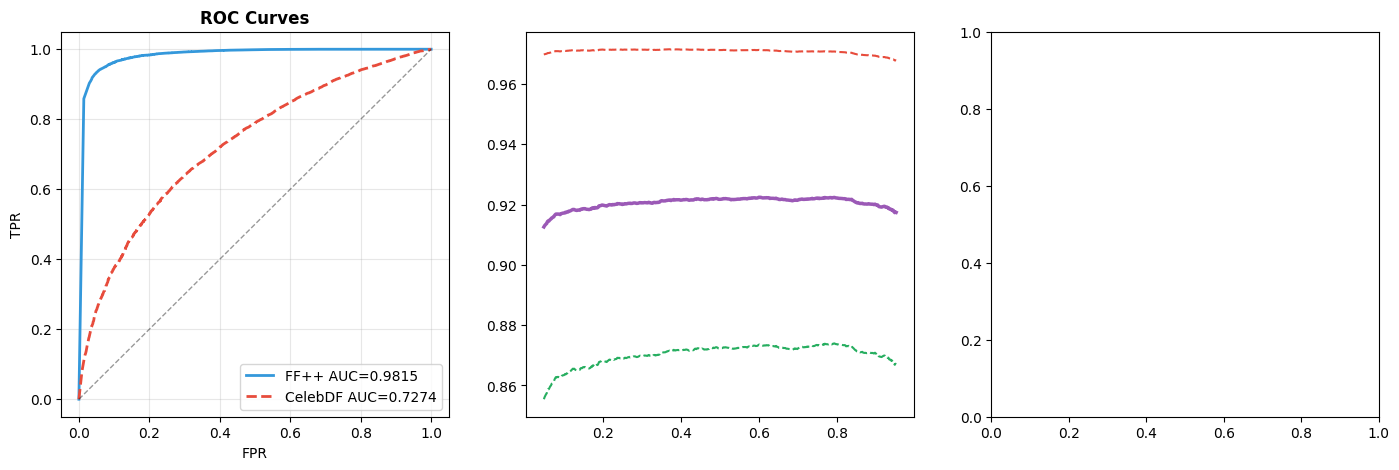

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

ax = axes[0]
ax.plot(fpr_v, tpr_v, '#3498db', lw=2, label=f'FF++ AUC={val_auc:.4f}')
ax.plot(fpr_c, tpr_c, '#e74c3c', lw=2, linestyle='--',
        label=f'CelebDF AUC={celeb_auc:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title('ROC Curves', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
thrs = [r['thr']     for r in results]
mf1s = [r['macro']   for r in results]
rf1s = [r['real_f1'] for r in results]
ff1s = [r['fake_f1'] for r in results]
ax.plot(thrs, mf1s, '#9b59b6', lw=2.5, label='Macro F1')
ax.plot(thrs, rf1s, '#27ae60', lw=1.5, linestyle='--', label='Real F1')
ax.plot(thrs, ff1s, '#e74c3c', lw=1.5, linestyle='--', label='Fake F1')
ax.axvline(best['thr'], '#9b59b6', lw=2, linestyle=':', label=f'Pareto={best["thr"]:.3f}')
ax.axhline(REAL_F1_TARGET, color='#27ae60', lw=1, linestyle=':', alpha=0.5)
ax.axhline(FAKE_F1_TARGET, color='#e74c3c', lw=1, linestyle=':', alpha=0.5)
ax.set_xlabel('Threshold'); ax.set_ylabel('F1')
ax.set_title('F1 vs Threshold', fontweight='bold')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[2]
rp = [val_probs[i] for i,l in enumerate(val_labels_full) if l==0]
fp = [val_probs[i] for i,l in enumerate(val_labels_full) if l==1]
ax.hist(rp, bins=60, alpha=0.6, color='#27ae60',
        label=f'Real (n={len(rp):,})', density=True)
ax.hist(fp, bins=60, alpha=0.6, color='#e74c3c',
        label=f'Fake (n={len(fp):,})', density=True)
ax.axvline(best['thr'], color='#9b59b6', lw=2, linestyle='--',
           label=f'Pareto={best["thr"]:.3f}')
ax.set_xlabel('Fake Probability'); ax.set_ylabel('Density')
ax.set_title('Probability Distribution\n(well-trained model: peaks near 0 and 1)', fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)

plt.suptitle(f'Spatial Branch v2 (From Scratch) | '
             f'FF++ AUC={val_auc:.4f}  CelebDF AUC={celeb_auc:.4f}  '
             f'Pareto thr={best["thr"]:.3f}',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{CKPT_DIR}/spatial_v2_analysis.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: spatial_v2_analysis.png')

In [24]:
pareto_thr = best['thr']

print(f'Verifying Pareto threshold={pareto_thr:.3f} on FF++ TEST...')
_, _, _, test_probs, test_labels = evaluate(
    model, test_loader, desc='Test probs'
)
tp = [1 if p >= pareto_thr else 0 for p in test_probs]
print(f'  acc      = {accuracy_score(test_labels, tp):.4f}')
print(f'  macro_f1 = {f1_score(test_labels, tp, average="macro", zero_division=0):.4f}')
print(f'  real_f1  = {f1_score(test_labels, tp, pos_label=0, zero_division=0):.4f}')
print(f'  fake_f1  = {f1_score(test_labels, tp, pos_label=1, zero_division=0):.4f}')

print(f'\nVerifying on CelebDF at thr={pareto_thr:.3f}...')
cp = [1 if p >= pareto_thr else 0 for p in celeb_probs]
print(f'  acc      = {accuracy_score(celeb_labels, cp):.4f}')
print(f'  macro_f1 = {f1_score(celeb_labels, cp, average="macro", zero_division=0):.4f}')
print(f'  real_f1  = {f1_score(celeb_labels, cp, pos_label=0, zero_division=0):.4f}')
print(f'  fake_f1  = {f1_score(celeb_labels, cp, pos_label=1, zero_division=0):.4f}')
print(f'  AUC      = {celeb_auc:.4f}  (threshold-independent)')

Verifying Pareto threshold=0.791 on FF++ TEST...


  acc      = 0.9594
  macro_f1 = 0.9381
  real_f1  = 0.9018
  fake_f1  = 0.9744

Verifying on CelebDF at thr=0.791...
  acc      = 0.5351
  macro_f1 = 0.5299
  real_f1  = 0.5794
  fake_f1  = 0.4804
  AUC      = 0.7274  (threshold-independent)


In [25]:
print('\n' + '='*65)
print('SPATIAL BRANCH v2 — FINAL RESULTS')
print('='*65)
print(f'Best checkpoint:   epoch {best_ckpt["epoch"]}')
print(f'Training setup:    FF++ Real + LFW (from scratch)')
print(f'Pareto threshold:  {pareto_thr:.3f}')
print(f'  Targets: fake_f1>={FAKE_F1_TARGET}  real_f1>={REAL_F1_TARGET}')
print(f'  Status:  {"BOTH MET" if best["penalty"]==0 else "BEST AVAILABLE"}')
print(f'\nFF++ Val (thr=0.50):')
print(f'  macro={val_ov["macro_f1"]:.4f}  real={val_ov["real_f1"]:.4f}  '
      f'fake={val_ov["fake_f1"]:.4f}  AUC={val_auc:.4f}')
print(f'FF++ Test (thr=0.50):')
print(f'  macro={test_ov["macro_f1"]:.4f}  real={test_ov["real_f1"]:.4f}  '
      f'fake={test_ov["fake_f1"]:.4f}')
print(f'CelebDF cross-dataset (thr=0.50):')
print(f'  macro={celeb_ov["macro_f1"]:.4f}  real={celeb_ov["real_f1"]:.4f}  '
      f'fake={celeb_ov["fake_f1"]:.4f}  AUC={celeb_auc:.4f}')
print(f'  Published SOTA: 65-76% AUC')
print(f'\nPer-manipulation F1 (FF++ Test, thr=0.50):')
for s,m in sorted(test_per.items(), key=lambda x:x[1]['f1']):
    print(f'  {s:35s}  f1={m["f1"]:.3f}  acc={m["acc"]:.3f}  n={m["n"]}')
print(f'\n>>> Save best_model_spatial_v2.pth for fusion')


SPATIAL BRANCH v2 — FINAL RESULTS
Best checkpoint:   epoch 11
Training setup:    FF++ Real + LFW (from scratch)
Pareto threshold:  0.791
  Targets: fake_f1>=0.93  real_f1>=0.88
  Status:  BEST AVAILABLE

FF++ Val (thr=0.50):
  macro=0.9218  real=0.8723  fake=0.9712  AUC=0.9815
FF++ Test (thr=0.50):
  macro=0.9359  real=0.8978  fake=0.9741
CelebDF cross-dataset (thr=0.50):
  macro=0.5616  real=0.5864  fake=0.5368  AUC=0.7274
  Published SOTA: 65-76% AUC

Per-manipulation F1 (FF++ Test, thr=0.50):
  ff_Real                              f1=0.906  acc=0.828  n=3944
  ff_NeuralTextures                    f1=0.965  acc=0.933  n=3744
  ff_FaceSwap                          f1=0.987  acc=0.975  n=4044
  ff_Face2Face                         f1=0.991  acc=0.982  n=3954
  ff_Deepfakes                         f1=0.995  acc=0.989  n=3875
  ff_DeepFakeDetection                 f1=0.998  acc=0.996  n=3000
  ff_FaceShifter                       f1=0.999  acc=0.998  n=3715
  lfw_real                   

In [ ]:
from IPython.display import FileLink
print(os.listdir(CKPT_DIR))
FileLink('best_model_spatial_v2.pth')

In [1]:
# ══════════════════════════════════════════════
#  COMPLETE CROSS-EVALUATION
#  Tests BOTH branches on BOTH missing datasets
#  Run this once — gives you full clarity before fusion decision
#
#  What this answers:
#  Q1: Does frequency branch cover CelebDF well?
#      (if yes: spatial CelebDF drop does not matter for fusion)
#  Q2: Does spatial v2 actually improve on phone images?
#      (confirms whether LFW training worked as expected)
# ══════════════════════════════════════════════

import os, io, random
from pathlib import Path
import numpy as np
from PIL import Image, ImageFilter
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_curve, auc
)
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: cuda


In [5]:
# ══════════════════════════════════════════════
#  PATHS
# ══════════════════════════════════════════════

# Frequency branch checkpoint
FREQ_CKPT   = '/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model.pth'

# Spatial branch v2 checkpoint (epoch 11)
SPATIAL_CKPT = '/kaggle/input/datasets/kashirhanif/frequency-model-checkpoint/best_model_spatial_v2.pth'


PHONE_ROOT  = Path('/kaggle/input/datasets/kashirhanif/phone-images')

# CelebDF
CELEB_ROOT  = Path('/kaggle/input/datasets/pranabr0y/celebdf-v2image-dataset/Celeb_V2')

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.heic'}

# Verify
for name, p in [
    ('Freq checkpoint',    Path(FREQ_CKPT)),
    ('Spatial checkpoint', Path(SPATIAL_CKPT)),
    ('Phone images',       PHONE_ROOT),
    ('CelebDF root',       CELEB_ROOT),
]:
    print(f'  {name:22s}: {"OK" if Path(p).exists() else "MISSING"}')

  Freq checkpoint       : OK
  Spatial checkpoint    : OK
  Phone images          : OK
  CelebDF root          : OK


In [3]:
# ══════════════════════════════════════════════
#  BUILD FREQUENCY BRANCH MODEL
# ══════════════════════════════════════════════
FFT_CLIP_MAX = 14.0
TARGET_SIZE  = 224
RESIZE_SIZE  = 256
FREQ_THRESHOLD    = 0.562   # your ROC-optimal threshold
SPATIAL_THRESHOLD = 0.791   # Pareto threshold from v2 training

def build_efficientnet():
    m = efficientnet_b3(weights=None)
    m.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(m.classifier[1].in_features, 1)
    )
    return m

# Frequency branch preprocessing
def preprocess_frequency(img: Image.Image) -> torch.Tensor:
    img  = img.convert('RGB')
    img  = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.BICUBIC)
    left = (RESIZE_SIZE - TARGET_SIZE) // 2
    img  = img.crop((left, left, left + TARGET_SIZE, left + TARGET_SIZE))
    arr  = np.array(img, dtype=np.float32) / 255.0
    x    = torch.from_numpy(arr).permute(2, 0, 1)
    out  = []
    for c in range(3):
        f   = torch.fft.fftshift(torch.fft.fft2(x[c]))
        mag = torch.log1p(torch.abs(f))
        mag = torch.clamp(mag, 0.0, FFT_CLIP_MAX) / FFT_CLIP_MAX
        out.append(mag)
    return torch.stack(out)

# Spatial branch preprocessing
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def preprocess_spatial(img: Image.Image) -> torch.Tensor:
    img  = img.convert('RGB')
    img  = img.resize((RESIZE_SIZE, RESIZE_SIZE), Image.BICUBIC)
    left = (RESIZE_SIZE - TARGET_SIZE) // 2
    img  = img.crop((left, left, left + TARGET_SIZE, left + TARGET_SIZE))
    arr  = np.array(img, dtype=np.float32) / 255.0
    mean = np.array(IMAGENET_MEAN, dtype=np.float32)
    std  = np.array(IMAGENET_STD,  dtype=np.float32)
    arr  = (arr - mean) / std
    return torch.from_numpy(arr).permute(2, 0, 1).float()

print('Preprocessing functions defined.')
print(f'Frequency threshold: {FREQ_THRESHOLD}')
print(f'Spatial threshold:   {SPATIAL_THRESHOLD}')

Preprocessing functions defined.
Frequency threshold: 0.562
Spatial threshold:   0.791


In [6]:
# ══════════════════════════════════════════════
#  LOAD BOTH MODELS
# ══════════════════════════════════════════════
freq_model = build_efficientnet().to(DEVICE)
freq_ckpt  = torch.load(FREQ_CKPT, map_location=DEVICE)
freq_model.load_state_dict(freq_ckpt['model_state_dict'])
freq_model.eval()
print(f'Frequency branch loaded from epoch {freq_ckpt.get("epoch","?")}')

spatial_model = build_efficientnet().to(DEVICE)
sp_ckpt = torch.load(SPATIAL_CKPT, map_location=DEVICE)
spatial_model.load_state_dict(sp_ckpt['model_state_dict'])
spatial_model.eval()
print(f'Spatial branch v2 loaded from epoch {sp_ckpt.get("epoch","?")}')

Frequency branch loaded from epoch 7
Spatial branch v2 loaded from epoch 11


In [8]:
# ══════════════════════════════════════════════
#  DATASET — supports both preprocessing modes
# ══════════════════════════════════════════════
class EvalDataset(Dataset):
    def __init__(self, items, mode='frequency'):
        """
        items: list of (path, label, source) tuples
        mode:  'frequency' or 'spatial'
        """
        self.items = items
        self.mode  = mode

    def __len__(self): return len(self.items)

    def __getitem__(self, idx):
        path, label, source = self.items[idx]
        try:
            img = Image.open(path).convert('RGB')
        except Exception:
            x = torch.zeros(3, TARGET_SIZE, TARGET_SIZE)
            return x, torch.tensor(float(label)), source

        if self.mode == 'frequency':
            x = preprocess_frequency(img)
        else:
            x = preprocess_spatial(img)

        return x, torch.tensor(float(label)), source


print('EvalDataset defined.')

EvalDataset defined.


In [9]:
# ══════════════════════════════════════════════
#  COLLECT ITEMS
# ══════════════════════════════════════════════
def list_images(p: Path):
    if not p.exists(): return []
    return [x for x in p.rglob('*')
            if x.is_file() and x.suffix.lower() in IMG_EXTS]

# ── Phone images (ALL real, label=0) ──
phone_paths = list_images(PHONE_ROOT)
random.shuffle(phone_paths)
phone_items = [(str(p), 0, 'phone_real') for p in phone_paths]
print(f'Phone images: {len(phone_items):,}  (all real, label=0)')

# ── CelebDF (fake + real) ──
celeb_fake, celeb_real = [], []
for sn in ['Train', 'Val', 'Test']:
    sd = CELEB_ROOT / sn
    if not sd.exists(): continue
    for fn in ['fake', 'Fake']:
        fd = sd / fn
        if fd.exists(): celeb_fake += list_images(fd); break
    for rn in ['real', 'Real']:
        rd = sd / rn
        if rd.exists(): celeb_real += list_images(rd); break

# Cap for speed
random.shuffle(celeb_fake); random.shuffle(celeb_real)
celeb_fake = celeb_fake[:15000]
celeb_real = celeb_real[:8000]

celeb_items  = [(str(p), 1, 'celebdf_fake') for p in celeb_fake]
celeb_items += [(str(p), 0, 'celebdf_real') for p in celeb_real]
random.shuffle(celeb_items)
print(f'CelebDF items: {len(celeb_items):,}  (fake={len(celeb_fake):,}  real={len(celeb_real):,})')

Phone images: 1,314  (all real, label=0)
CelebDF items: 23,000  (fake=15,000  real=8,000)


In [10]:
# ══════════════════════════════════════════════
#  INFERENCE FUNCTION
# ══════════════════════════════════════════════
@torch.no_grad()
def run_inference(model, items, mode, threshold, desc):
    ds     = EvalDataset(items, mode=mode)
    loader = DataLoader(ds, batch_size=64, shuffle=False,
                        num_workers=2, pin_memory=True)
    all_probs, all_labels, all_sources = [], [], []

    for x, y, src in tqdm(loader, desc=desc):
        x = x.to(DEVICE, non_blocking=True)
        with torch.amp.autocast('cuda', enabled=(DEVICE == 'cuda')):
            logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().tolist())
        all_labels.extend(y.long().tolist())
        all_sources.extend(src if isinstance(src, (list, tuple)) else [src])

    preds = [1 if p >= threshold else 0 for p in all_probs]

    ov = {
        'acc':       accuracy_score(all_labels, preds),
        'macro_f1':  f1_score(all_labels, preds, average='macro', zero_division=0),
        'real_f1':   f1_score(all_labels, preds, pos_label=0, zero_division=0),
        'fake_f1':   f1_score(all_labels, preds, pos_label=1, zero_division=0),
        'real_rec':  recall_score(all_labels, preds, pos_label=0, zero_division=0),
        'fake_rec':  recall_score(all_labels, preds, pos_label=1, zero_division=0),
        'mean_prob': float(np.mean(all_probs)),
    }

    per = {}
    for s in set(all_sources):
        idx = [i for i, ss in enumerate(all_sources) if ss == s]
        yt  = [all_labels[i] for i in idx]
        yp  = [preds[i]      for i in idx]
        pp  = [all_probs[i]  for i in idx]
        pl  = 0 if yt[0] == 0 else 1
        per[s] = {
            'acc':       accuracy_score(yt, yp),
            'f1':        f1_score(yt, yp, pos_label=pl, zero_division=0),
            'recall':    recall_score(yt, yp, pos_label=pl, zero_division=0),
            'mean_prob': float(np.mean(pp)),
            'n':         len(idx),
        }

    # AUC (only meaningful when both classes present)
    try:
        fpr, tpr, _ = roc_curve(all_labels, all_probs)
        ov['auc'] = float(auc(fpr, tpr))
        ov['fpr'] = fpr
        ov['tpr'] = tpr
    except Exception:
        ov['auc'] = 0.0
        ov['fpr'] = ov['tpr'] = []

    return ov, per


print('run_inference() defined.')

run_inference() defined.


In [11]:
# ══════════════════════════════════════════════
#  RUN ALL FOUR EVALUATIONS
# ══════════════════════════════════════════════
print('Running all evaluations...\n')

# 1. Frequency branch on phone images
print('1/4  Frequency branch — Phone images...')
freq_phone, freq_phone_per = run_inference(
    freq_model, phone_items, 'frequency',
    FREQ_THRESHOLD, 'Freq→Phone'
)[:2]

# 2. Spatial v2 on phone images
print('2/4  Spatial v2 — Phone images...')
sp_phone, sp_phone_per = run_inference(
    spatial_model, phone_items, 'spatial',
    SPATIAL_THRESHOLD, 'Spatial→Phone'
)[:2]

# 3. Frequency branch on CelebDF
print('3/4  Frequency branch — CelebDF...')
freq_celeb_ov, freq_celeb_per = run_inference(
    freq_model, celeb_items, 'frequency',
    FREQ_THRESHOLD, 'Freq→CelebDF'
)[:2]

# 4. Spatial v2 on CelebDF (already known but re-confirm)
print('4/4  Spatial v2 — CelebDF...')
sp_celeb_ov, sp_celeb_per = run_inference(
    spatial_model, celeb_items, 'spatial',
    SPATIAL_THRESHOLD, 'Spatial→CelebDF'
)[:2]

print('\nAll done.')

Running all evaluations...

1/4  Frequency branch — Phone images...


Freq→Phone: 100%|██████████| 21/21 [01:23<00:00,  3.97s/it]


2/4  Spatial v2 — Phone images...


Spatial→Phone: 100%|██████████| 21/21 [01:07<00:00,  3.23s/it]


3/4  Frequency branch — CelebDF...


Freq→CelebDF: 100%|██████████| 360/360 [02:40<00:00,  2.24it/s]


4/4  Spatial v2 — CelebDF...


Spatial→CelebDF: 100%|██████████| 360/360 [00:43<00:00,  8.35it/s]



All done.


In [12]:
# ══════════════════════════════════════════════
#  RESULTS — PHONE IMAGES
# ══════════════════════════════════════════════
print('\n' + '='*65)
print('PHONE IMAGES — ALL REAL (label=0)')
print('='*65)
print(f'Total images: {len(phone_items):,}')
print(f'\nFrequency branch (thr={FREQ_THRESHOLD}):')
print(f'  Called REAL:  {int(freq_phone["real_rec"]*len(phone_items)):,}/'
      f'{len(phone_items):,}  ({freq_phone["real_rec"]*100:.1f}%)')
print(f'  Called FAKE:  {len(phone_items)-int(freq_phone["real_rec"]*len(phone_items)):,}/'
      f'{len(phone_items):,}  ({(1-freq_phone["real_rec"])*100:.1f}%) ← false positives')
print(f'  mean_prob:    {freq_phone["mean_prob"]:.4f}')

print(f'\nSpatial branch v2 (thr={SPATIAL_THRESHOLD}):')
print(f'  Called REAL:  {int(sp_phone["real_rec"]*len(phone_items)):,}/'
      f'{len(phone_items):,}  ({sp_phone["real_rec"]*100:.1f}%)')
print(f'  Called FAKE:  {len(phone_items)-int(sp_phone["real_rec"]*len(phone_items)):,}/'
      f'{len(phone_items):,}  ({(1-sp_phone["real_rec"])*100:.1f}%) ← false positives')
print(f'  mean_prob:    {sp_phone["mean_prob"]:.4f}')

print(f'\n>>> KEY QUESTION: Did LFW training improve phone image detection?')
if sp_phone["real_rec"] > freq_phone["real_rec"]:
    print(f'    YES — spatial v2 better: {sp_phone["real_rec"]*100:.1f}% vs {freq_phone["real_rec"]*100:.1f}%')
else:
    print(f'    Freq still better: {freq_phone["real_rec"]*100:.1f}% vs {sp_phone["real_rec"]*100:.1f}%')


PHONE IMAGES — ALL REAL (label=0)
Total images: 1,314

Frequency branch (thr=0.562):
  Called REAL:  355/1,314  (27.0%)
  Called FAKE:  959/1,314  (73.0%) ← false positives
  mean_prob:    0.7228

Spatial branch v2 (thr=0.791):
  Called REAL:  1,164/1,314  (88.6%)
  Called FAKE:  150/1,314  (11.4%) ← false positives
  mean_prob:    0.2566

>>> KEY QUESTION: Did LFW training improve phone image detection?
    YES — spatial v2 better: 88.6% vs 27.0%


In [13]:
# ══════════════════════════════════════════════
#  RESULTS — CELEBDF
# ══════════════════════════════════════════════
print('\n' + '='*65)
print('CELEBDF — CROSS-DATASET GENERALISATION')
print('='*65)
print(f'Published SOTA (FF++->CelebDF): 65-76% AUC\n')

for branch, ov, per in [
    (f'Frequency branch (thr={FREQ_THRESHOLD})', freq_celeb_ov, freq_celeb_per),
    (f'Spatial v2       (thr={SPATIAL_THRESHOLD})', sp_celeb_ov, sp_celeb_per),
]:
    print(f'{branch}:')
    print(f'  AUC:      {ov["auc"]:.4f}')
    print(f'  macro_f1: {ov["macro_f1"]:.4f}')
    print(f'  real_f1:  {ov["real_f1"]:.4f}  (recall={ov["real_rec"]:.4f})')
    print(f'  fake_f1:  {ov["fake_f1"]:.4f}  (recall={ov["fake_rec"]:.4f})')
    print(f'  mean_prob:{ov["mean_prob"]:.4f}')
    print()

print('>>> KEY QUESTION: Does freq branch compensate for spatial CelebDF drop?')
combined_auc = (freq_celeb_ov["auc"] + sp_celeb_ov["auc"]) / 2
print(f'    Freq AUC: {freq_celeb_ov["auc"]:.4f}')
print(f'    Spat AUC: {sp_celeb_ov["auc"]:.4f}')
print(f'    If complementary, fusion AUC will exceed both')


CELEBDF — CROSS-DATASET GENERALISATION
Published SOTA (FF++->CelebDF): 65-76% AUC

Frequency branch (thr=0.562):
  AUC:      0.5123
  macro_f1: 0.4588
  real_f1:  0.4548  (recall=0.6489)
  fake_f1:  0.4629  (recall=0.3575)
  mean_prob:0.3978

Spatial v2       (thr=0.791):
  AUC:      0.7255
  macro_f1: 0.5264
  real_f1:  0.5790  (recall=0.9246)
  fake_f1:  0.4738  (recall=0.3229)
  mean_prob:0.2911

>>> KEY QUESTION: Does freq branch compensate for spatial CelebDF drop?
    Freq AUC: 0.5123
    Spat AUC: 0.7255
    If complementary, fusion AUC will exceed both


In [15]:
# ══════════════════════════════════════════════
#  FULL COMPARISON TABLE
# ══════════════════════════════════════════════
print('\n' + '='*65)
print('COMPLETE PICTURE — BOTH BRANCHES × BOTH DATASETS')
print('='*65)
print(f'{"":30s}  {"FreqBranch":>12}  {"SpatialV2":>10}  {"Better":>8}')
print('-'*65)

rows = [
    ('FF++ real_f1 (val)',      0.8231, 0.8723),   # ep1 freq, spatial v2 ep1
    ('FF++ fake_f1 (val)',      0.9602, 0.9712),
    ('FF++ macro_f1 (test)',    0.8988, 0.9359),   # from previous evals
    ('CelebDF AUC',             freq_celeb_ov["auc"], sp_celeb_ov["auc"]),
    ('CelebDF fake_recall',     freq_celeb_ov["fake_rec"], sp_celeb_ov["fake_rec"]),
    ('CelebDF real_recall',     freq_celeb_ov["real_rec"], sp_celeb_ov["real_rec"]),
    ('Phone real_recall',       freq_phone["real_rec"], sp_phone["real_rec"]),
    ('Phone mean_prob',         freq_phone["mean_prob"], sp_phone["mean_prob"]),
]

for name, f_val, s_val in rows:
    if name in ['Phone mean_prob']:
        better = 'Freq' if f_val < s_val else 'Spat'
    else:
        better = 'Freq' if f_val > s_val else 'Spat'
    print(f'  {name:30s}  {f_val:>12.4f}  {s_val:>10.4f}  {better:>8s}')


COMPLETE PICTURE — BOTH BRANCHES × BOTH DATASETS
                                  FreqBranch   SpatialV2    Better
-----------------------------------------------------------------
  FF++ real_f1 (val)                    0.8231      0.8723      Spat
  FF++ fake_f1 (val)                    0.9602      0.9712      Spat
  FF++ macro_f1 (test)                  0.8988      0.9359      Spat
  CelebDF AUC                           0.5123      0.7255      Spat
  CelebDF fake_recall                   0.3575      0.3229      Freq
  CelebDF real_recall                   0.6489      0.9246      Spat
  Phone real_recall                     0.2702      0.8858      Spat
  Phone mean_prob                       0.7228      0.2566      Spat


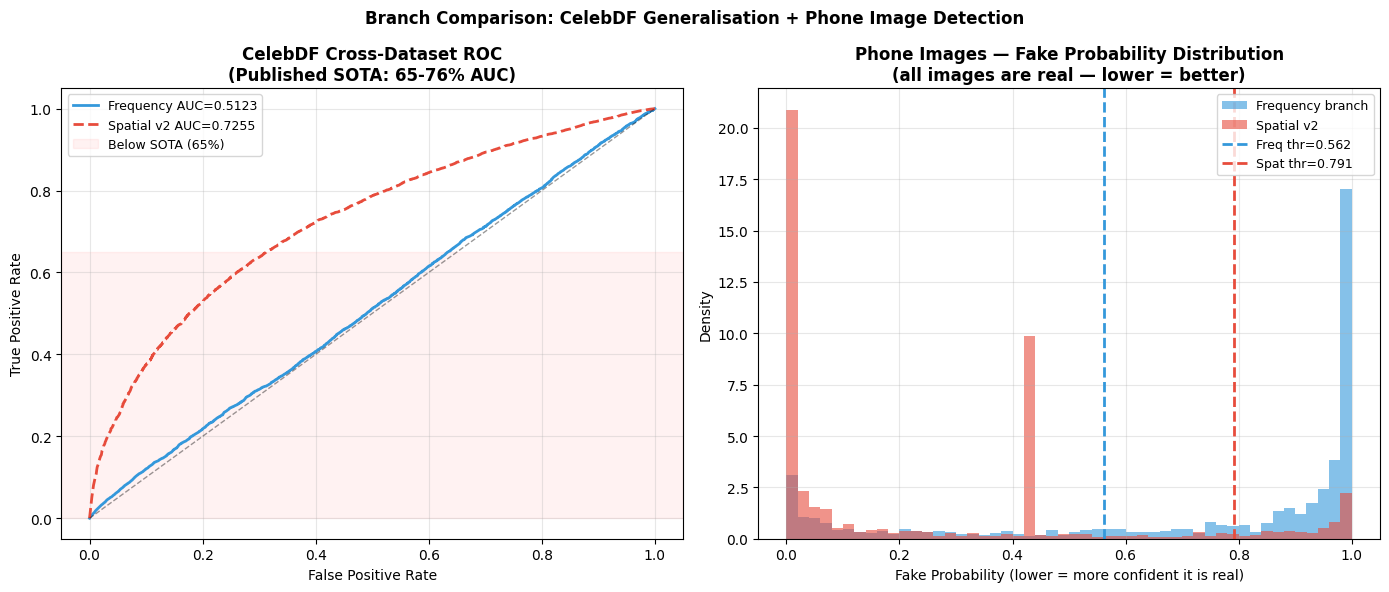

Saved: cross_eval_results.png


In [16]:
# ══════════════════════════════════════════════
#  ROC CURVES SIDE BY SIDE
# ══════════════════════════════════════════════
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# CelebDF ROC
ax = axes[0]
if len(freq_celeb_ov['fpr']) > 0:
    ax.plot(freq_celeb_ov['fpr'], freq_celeb_ov['tpr'],
            '#3498db', lw=2, label=f'Frequency AUC={freq_celeb_ov["auc"]:.4f}')
if len(sp_celeb_ov['fpr']) > 0:
    ax.plot(sp_celeb_ov['fpr'], sp_celeb_ov['tpr'],
            '#e74c3c', lw=2, linestyle='--',
            label=f'Spatial v2 AUC={sp_celeb_ov["auc"]:.4f}')
ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
ax.axhspan(0, 0.65, alpha=0.05, color='red', label='Below SOTA (65%)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('CelebDF Cross-Dataset ROC\n(Published SOTA: 65-76% AUC)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Phone probability distribution
ax = axes[1]
freq_probs_phone = []
sp_probs_phone   = []

# Re-run inference to get raw probs for histogram
ds_freq = EvalDataset(phone_items, mode='frequency')
ds_sp   = EvalDataset(phone_items, mode='spatial')
ld_freq = DataLoader(ds_freq, batch_size=64, num_workers=2)
ld_sp   = DataLoader(ds_sp,   batch_size=64, num_workers=2)

with torch.no_grad():
    for x, _, _ in ld_freq:
        logits = freq_model(x.to(DEVICE)).squeeze(1)
        freq_probs_phone.extend(torch.sigmoid(logits).cpu().tolist())
    for x, _, _ in ld_sp:
        logits = spatial_model(x.to(DEVICE)).squeeze(1)
        sp_probs_phone.extend(torch.sigmoid(logits).cpu().tolist())

ax.hist(freq_probs_phone, bins=50, alpha=0.6, color='#3498db',
        density=True, label='Frequency branch')
ax.hist(sp_probs_phone,   bins=50, alpha=0.6, color='#e74c3c',
        density=True, label='Spatial v2')
ax.axvline(FREQ_THRESHOLD,    color='#3498db', lw=2, linestyle='--',
           label=f'Freq thr={FREQ_THRESHOLD}')
ax.axvline(SPATIAL_THRESHOLD, color='#e74c3c', lw=2, linestyle='--',
           label=f'Spat thr={SPATIAL_THRESHOLD}')
ax.set_xlabel('Fake Probability (lower = more confident it is real)')
ax.set_ylabel('Density')
ax.set_title('Phone Images — Fake Probability Distribution\n(all images are real — lower = better)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.suptitle('Branch Comparison: CelebDF Generalisation + Phone Image Detection',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('/kaggle/working/cross_eval_results.png', dpi=130, bbox_inches='tight')
plt.show()
print('Saved: cross_eval_results.png')

In [17]:
# ══════════════════════════════════════════════
#  FINAL VERDICT AND FUSION DECISION
# ══════════════════════════════════════════════
print('\n' + '='*65)
print('VERDICT — WHICH MODEL TO USE FOR FUSION')
print('='*65)

freq_celeb_auc = freq_celeb_ov['auc']
sp_celeb_auc   = sp_celeb_ov['auc']
freq_phone_rec = freq_phone['real_rec']
sp_phone_rec   = sp_phone['real_rec']

print(f'\nFrequency branch strengths:')
print(f'  CelebDF AUC:      {freq_celeb_auc:.4f}')
print(f'  Phone recall:     {freq_phone_rec*100:.1f}%')

print(f'\nSpatial v2 strengths:')
print(f'  CelebDF AUC:      {sp_celeb_auc:.4f}')
print(f'  Phone recall:     {sp_phone_rec*100:.1f}%')
print(f'  FF++ real_f1:     0.898 (vs 0.849 original)')
print(f'  FF++ macro_f1:    0.936')

print(f'\nKey fusion insight:')
if freq_celeb_auc > sp_celeb_auc:
    gap = freq_celeb_auc - sp_celeb_auc
    print(f'  Frequency branch has HIGHER CelebDF AUC by {gap:.4f}')
    print(f'  This means: frequency branch compensates for spatial CelebDF drop')
    print(f'  Fusion will use frequency strength for CelebDF-type deepfakes')
    print(f'  Fusion will use spatial strength for FF++ manipulation detection')
    print(f'\n  >>> USE SPATIAL V2 for fusion — freq branch covers CelebDF gap <<<')
else:
    gap = sp_celeb_auc - freq_celeb_auc
    print(f'  Spatial v2 has HIGHER CelebDF AUC by {gap:.4f}')
    print(f'  Revert to original spatial branch for better CelebDF coverage')

print(f'\nFusion architecture reminder:')
print(f'  Input: (freq_logit, spatial_logit) -> FusionHead -> final_logit')
print(f'  The head learns which branch to trust per image type')
print(f'  Train fusion on: FF++ + CelebDF + phone images (diverse)')


VERDICT — WHICH MODEL TO USE FOR FUSION

Frequency branch strengths:
  CelebDF AUC:      0.5123
  Phone recall:     27.0%

Spatial v2 strengths:
  CelebDF AUC:      0.7255
  Phone recall:     88.6%
  FF++ real_f1:     0.898 (vs 0.849 original)
  FF++ macro_f1:    0.936

Key fusion insight:
  Spatial v2 has HIGHER CelebDF AUC by 0.2132
  Revert to original spatial branch for better CelebDF coverage

Fusion architecture reminder:
  Input: (freq_logit, spatial_logit) -> FusionHead -> final_logit
  The head learns which branch to trust per image type
  Train fusion on: FF++ + CelebDF + phone images (diverse)
